### Flight Risk - Data Preparation

In [1]:
import os

import pandas as pd
import numpy as np

from pathlib import Path
import lightgbm as lgb
from dotenv import load_dotenv
import holidays as br_holidays

In [2]:
# ENV vars
load_dotenv()

START_YEAR = os.environ.get('START_YEAR')
END_YEAR = os.environ.get('END_YEAR')

In [3]:
# Loading raw data

data = pd.read_parquet(Path.cwd().parent / ".data" / "flights_with_weather.parquet")

data["dep_actual"] = pd.to_datetime(data["dep_actual"])
data["arr_actual"] = pd.to_datetime(data["arr_actual"])

data.tail(20)


,airline_icao,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,origin_type,origin_lat,origin_lon,...,origin_wx_cloudcover,origin_wx_weathercode,origin_wx_surface_pressure,destination_wx_temperature_2m,destination_wx_precipitation,destination_wx_windspeed_10m,destination_wx_windgusts_10m,destination_wx_cloudcover,destination_wx_weathercode,destination_wx_surface_pressure
2967356,TAM,SBGR,SBPA,2025-12-22 09:50:00,2025-12-22 09:56:00,2025-12-22 11:35:00,2025-12-22 11:34:00,large_airport,-23.431274,-46.469954,...,31.0,1.0,932.024963,30.650000,0.0,6.542201,20.880001,45.0,1.0,1008.073242
2967357,TAM,SBGR,SBJP,2025-12-21 14:15:00,2025-12-21 14:20:00,2025-12-21 17:30:00,2025-12-21 17:32:00,large_airport,-23.431274,-46.469954,...,32.0,1.0,931.980469,27.049999,0.0,18.218275,42.839996,45.0,1.0,1003.385498
2967358,TAM,SBGR,SBJP,2025-12-22 14:15:00,2025-12-22 16:02:00,2025-12-22 17:30:00,2025-12-22 19:09:00,large_airport,-23.431274,-46.469954,...,91.0,3.0,930.975647,26.900000,0.0,14.588885,34.560001,98.0,3.0,1004.275452
2967359,TAM,SBGR,SBJP,2025-12-26 14:15:00,2025-12-26 14:23:00,2025-12-26 17:30:00,2025-12-26 17:48:00,large_airport,-23.431274,-46.469954,...,99.0,61.0,932.237732,26.900000,0.0,15.056652,36.360001,97.0,3.0,1005.566162
2967360,TAM,SBVT,SBGR,2025-12-25 04:10:00,2025-12-25 04:00:00,2025-12-25 05:55:00,2025-12-25 05:28:00,large_airport,-20.258000,-40.285000,...,1.0,0.0,1012.448792,21.450001,0.0,3.065289,7.559999,90.0,3.0,930.207092
2967361,TAM,SBFI,SBSP,2025-12-16 04:55:00,2025-12-16 04:57:00,2025-12-16 06:35:00,2025-12-16 06:21:00,large_airport,-25.594167,-54.489444,...,100.0,51.0,981.503723,21.400000,0.0,8.534353,18.000000,99.0,3.0,921.640381
2967362,TAM,SBFI,SBSP,2025-12-18 04:55:00,2025-12-18 05:00:00,2025-12-18 06:35:00,2025-12-18 06:31:00,large_airport,-25.594167,-54.489444,...,32.0,1.0,983.549072,16.049999,0.0,7.493277,16.919998,99.0,3.0,925.100769
2967363,TAM,SBFI,SBSP,2025-12-19 04:55:00,2025-12-19 04:53:00,2025-12-19 06:45:00,2025-12-19 06:28:00,large_airport,-25.594167,-54.489444,...,94.0,3.0,984.098022,18.299999,0.0,6.955084,17.280001,95.0,3.0,925.397766
2967364,TAM,SBFI,SBSP,2025-12-20 05:10:00,2025-12-20 10:05:00,2025-12-20 06:50:00,2025-12-20 11:32:00,large_airport,-25.594167,-54.489444,...,0.0,0.0,983.549072,19.100000,0.0,6.162207,15.480000,100.0,3.0,926.451111
2967365,TAM,SBFI,SBSP,2025-12-21 08:10:00,2025-12-21 08:12:00,2025-12-21 09:50:00,2025-12-21 09:55:00,large_airport,-25.594167,-54.489444,...,100.0,3.0,983.404297,23.700001,0.0,5.247857,19.080000,1.0,0.0,927.585449


In [4]:
data.columns

Index(['airline_icao', 'origin_icao', 'destination_icao', 'dep_scheduled',
       'dep_actual', 'arr_scheduled', 'arr_actual', 'origin_type',
       'origin_lat', 'origin_lon', 'origin_elevation_ft', 'origin_region',
       'destination_type', 'destination_lat', 'destination_lon',
       'destination_elevation_ft', 'destination_region',
       'origin_wx_temperature_2m', 'origin_wx_precipitation',
       'origin_wx_windspeed_10m', 'origin_wx_windgusts_10m',
       'origin_wx_cloudcover', 'origin_wx_weathercode',
       'origin_wx_surface_pressure', 'destination_wx_temperature_2m',
       'destination_wx_precipitation', 'destination_wx_windspeed_10m',
       'destination_wx_windgusts_10m', 'destination_wx_cloudcover',
       'destination_wx_weathercode', 'destination_wx_surface_pressure'],
      dtype='str')

In [5]:
data.shape

(2967376, 31)

In [6]:
data.shape

(2967376, 31)

In [7]:
data.shape

(2967376, 31)

In [8]:
data.dtypes

airline_icao                                  str
origin_icao                                   str
destination_icao                              str
dep_scheduled                      datetime64[us]
dep_actual                         datetime64[us]
arr_scheduled                      datetime64[us]
arr_actual                         datetime64[us]
origin_type                                   str
origin_lat                                float64
origin_lon                                float64
origin_elevation_ft                       float64
origin_region                                 str
destination_type                              str
destination_lat                           float64
destination_lon                           float64
destination_elevation_ft                  float64
destination_region                            str
origin_wx_temperature_2m                  float32
origin_wx_precipitation                   float32
origin_wx_windspeed_10m                   float32


In [9]:
data.shape

(2967376, 31)

In [10]:
data.head()

,airline_icao,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,origin_type,origin_lat,origin_lon,...,origin_wx_cloudcover,origin_wx_weathercode,origin_wx_surface_pressure,destination_wx_temperature_2m,destination_wx_precipitation,destination_wx_windspeed_10m,destination_wx_windgusts_10m,destination_wx_cloudcover,destination_wx_weathercode,destination_wx_surface_pressure
0,TAM,SBRJ,SBGR,2022-01-06 14:20:00,2022-01-06 14:31:00,2022-01-06 15:25:00,2022-01-06 15:29:00,large_airport,-22.910397,-43.16282,...,92.0,3.0,1005.459106,22.600000,5.4,17.873556,34.560001,98.0,63.0,926.656494
1,TAM,SBRJ,SBGR,2022-01-07 14:20:00,2022-01-07 14:47:00,2022-01-07 15:25:00,2022-01-07 15:42:00,large_airport,-22.910397,-43.16282,...,100.0,53.0,1009.652283,21.400000,1.5,20.617662,39.599998,100.0,61.0,929.092102
2,TAM,SBRJ,SBGR,2022-01-08 14:20:00,2022-01-08 14:12:00,2022-01-08 15:25:00,2022-01-08 15:12:00,large_airport,-22.910397,-43.16282,...,100.0,53.0,1011.151184,20.000000,0.2,22.907431,44.279999,100.0,51.0,929.817139
3,TAM,SBRJ,SBGR,2022-01-09 14:20:00,2022-01-09 14:16:00,2022-01-09 15:25:00,2022-01-09 15:15:00,large_airport,-22.910397,-43.16282,...,100.0,51.0,1013.350769,20.100000,0.1,21.382906,38.519997,100.0,51.0,930.394958
4,TAM,SBRJ,SBGR,2022-01-11 14:20:00,2022-01-11 14:20:00,2022-01-11 15:25:00,2022-01-11 15:15:00,large_airport,-22.910397,-43.16282,...,100.0,3.0,1008.753906,25.200001,0.0,4.349896,16.199999,100.0,3.0,927.982117


### Feature Engineering

In [11]:
# Delay

data["dep_delay_min"] = (
    data["dep_actual"] - data["dep_scheduled"]
).dt.total_seconds() / 60

data["arr_delay_min"] = (
    data["arr_actual"] - data["arr_scheduled"]
).dt.total_seconds() / 60

In [12]:
data.shape

(2967376, 33)

In [13]:
data["origin_icao"].value_counts()

origin_icao
SBGR    350815
SBSP    348663
SBKP    208796
SBBR    202544
SBCF    193361
         ...  
SEQM         1
SVMI         1
MDPC         1
SCCF         1
SAAR         1
Name: count, Length: 204, dtype: int64

In [14]:
# removing extreme outliers
# arrived 24h+ before or 24h+ after
data = data[
    data["arr_delay_min"].between(-1440, 1440)
]
data.shape

(2967193, 33)

In [15]:
# target

data["delayed_15_min_plus"] = (
    data["arr_delay_min"] >= 15
)

In [16]:
# temporal data

data["year"] = data["dep_scheduled"].dt.year
data["month"] = data["dep_scheduled"].dt.month
data["day"] = data["dep_scheduled"].dt.day
data["weekday"] = data["dep_scheduled"].dt.weekday
data["hour"] = data["dep_scheduled"].dt.hour

In [17]:
# route

data["route"] = (
    data["origin_icao"] + "_" + data["destination_icao"]
)

data["scheduled_duration_min"] = (
    data["arr_scheduled"] - data["dep_scheduled"]
).dt.total_seconds() / 60


In [18]:
# bad weather
data["origin_bad_weather"]      = (data["origin_wx_weathercode"] >= 51).astype(int)
data["destination_bad_weather"] = (data["destination_wx_weathercode"] >= 51).astype(int)
data["both_bad_weather"]        = (data["origin_bad_weather"] & data["destination_bad_weather"]).astype(int)

# intensidade de chuva
data["origin_rain_intensity"] = pd.cut(
    data["origin_wx_precipitation"],
    bins=[-1, 0, 1, 5, 999],
    labels=[0, 1, 2, 3]
).astype(int)

# distância entre aeroportos
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

data["route_distance_km"] = haversine(
    data["origin_lat"], data["origin_lon"],
    data["destination_lat"], data["destination_lon"]
)

# diferença de altitude
data["altitude_diff_ft"] = data["destination_elevation_ft"] - data["origin_elevation_ft"]

# congestionamento do aeroporto: quantos voos saem da mesma origem na mesma hora
data["_dep_hour"] = data["dep_scheduled"].dt.floor("h")
airport_load = (
    data.groupby(["origin_icao", "_dep_hour"])
    .size()
    .rename("origin_airport_load")
    .reset_index()
)
data = data.merge(airport_load, on=["origin_icao", "_dep_hour"], how="left")
data = data.drop(columns=["_dep_hour"])

# feriados brasileiros (requer: pip install holidays)
import holidays as br_holidays

br_holiday_set = set(br_holidays.Brazil(years=range(2022, 2027)).keys())
data["dep_is_holiday"] = data["dep_scheduled"].dt.date.apply(
    lambda d: int(d in br_holiday_set)
)

# peak hour e weekend
data["dep_is_peak_hour"] = data["dep_scheduled"].dt.hour.isin([7, 8, 17, 18, 19, 20]).astype(int)
data["dep_is_weekend"]   = data["dep_scheduled"].dt.weekday.isin([5, 6]).astype(int)
# clima classificado (weathercodes WMO)
data["origin_wx_is_fog"]  = data["origin_wx_weathercode"].isin([45, 48]).astype(int)
data["origin_wx_is_rain"] = data["origin_wx_weathercode"].isin(
    [51, 53, 55, 61, 63, 65, 80, 81, 82]
).astype(int)

data["destination_wx_is_fog"]  = data["destination_wx_weathercode"].isin([45, 48]).astype(int)
data["destination_wx_is_rain"] = data["destination_wx_weathercode"].isin(
    [51, 53, 55, 61, 63, 65, 80, 81, 82]
).astype(int)

# tamanho do aeroporto (ordinal)
size_map = {"small_airport": 1, "medium_airport": 2, "large_airport": 3}
data["origin_airport_size"]      = data["origin_type"].map(size_map).fillna(1).astype(int)
data["destination_airport_size"] = data["destination_type"].map(size_map).fillna(1).astype(int)

# par de regiões
data["region_pair"] = data["origin_region"] + "_" + data["destination_region"]
data["same_region"] = (data["origin_region"] == data["destination_region"]).astype(int)

# rotas troncais de alta frequência
trunk_routes = {
    "SBGR_SBRJ", "SBRJ_SBGR",
    "SBSP_SBRJ", "SBRJ_SBSP",
    "SBGR_SBGL", "SBGL_SBGR",
    "SBGR_SBBR", "SBBR_SBGR",
    "SBSP_SBBR", "SBBR_SBSP",
    "SBGR_SBCF", "SBCF_SBGR",
}
data["is_trunk_route"] = data["route"].isin(trunk_routes).astype(int)


In [19]:
data.sample()

,airline_icao,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,origin_type,origin_lat,origin_lon,...,dep_is_weekend,origin_wx_is_fog,origin_wx_is_rain,destination_wx_is_fog,destination_wx_is_rain,origin_airport_size,destination_airport_size,region_pair,same_region,is_trunk_route
356397,TAM,SBSP,SBGO,2022-07-07 21:45:00,2022-07-07 21:52:00,2022-07-07 23:25:00,2022-07-07 23:25:00,large_airport,-23.627657,-46.654601,...,0,0,0,0,0,3,3,BR-SP_BR-GO,0,0


In [20]:
output_path = Path.cwd().parent / ".data" / "flight_delay_training.csv"
desired_output_cols = [
   "airline_icao",
   "origin_icao",
   "destination_icao",
   "route",
   "year",
   "month",
   "day",
   "weekday",
   "hour",
   "delayed_15_min_plus",
   "scheduled_duration_min"
]

In [21]:
data[desired_output_cols].to_csv(output_path, index=False)

## Treino

In [22]:
data_sorted = data.sort_values("dep_scheduled").reset_index(drop=True)

split_idx = int(len(data_sorted) * 0.8)
train = data_sorted.iloc[:split_idx].copy()
test  = data_sorted.iloc[split_idx:].copy()

In [23]:
global_rate = train["delayed_15_min_plus"].mean()
k = 50

rate_cols = ["route_delay_rate", "airline_delay_rate", "origin_delay_rate", "destination_delay_rate"]
train = train.drop(columns=[c for c in rate_cols if c in train.columns])
test  = test.drop(columns=[c for c in rate_cols if c in test.columns])

for col, feat_name in [
    ("route",            "route_delay_rate"),
    ("airline_icao",     "airline_delay_rate"),
    ("origin_icao",      "origin_delay_rate"),
    ("destination_icao", "destination_delay_rate"),
]:
    agg = (
        train.groupby(col)["delayed_15_min_plus"]
        .agg(["sum", "count"])
    )
    agg[feat_name] = (agg["sum"] + k * global_rate) / (agg["count"] + k)

    train = train.merge(agg[[feat_name]], on=col, how="left")
    test  = test.merge(agg[[feat_name]], on=col, how="left")
    train[feat_name] = train[feat_name].fillna(global_rate)
    test[feat_name]  = test[feat_name].fillna(global_rate)


In [24]:
X = [
    # identidade
    "airline_icao", "origin_icao", "destination_icao", "route",
    # aeroporto
    "origin_type", "origin_elevation_ft", "origin_region",
    "destination_type", "destination_elevation_ft", "destination_region",
    "origin_airport_size", "destination_airport_size",
    # temporal
    "month", "day", "weekday", "hour", "scheduled_duration_min",
    "dep_is_holiday", "dep_is_peak_hour", "dep_is_weekend",
    # rota
    "route_distance_km", "altitude_diff_ft",
    "region_pair", "same_region", "is_trunk_route",
    # congestionamento
    "origin_airport_load",
    # clima origem
    "origin_wx_temperature_2m", "origin_wx_precipitation",
    "origin_wx_windspeed_10m", "origin_wx_windgusts_10m",
    "origin_wx_cloudcover", "origin_wx_weathercode", "origin_wx_surface_pressure",
    "origin_bad_weather", "origin_rain_intensity",
    "origin_wx_is_fog", "origin_wx_is_rain",
    # clima destino
    "destination_wx_temperature_2m", "destination_wx_precipitation",
    "destination_wx_windspeed_10m", "destination_wx_windgusts_10m",
    "destination_wx_cloudcover", "destination_wx_weathercode", "destination_wx_surface_pressure",
    "destination_bad_weather", "destination_wx_is_fog", "destination_wx_is_rain",
    # combinado
    "both_bad_weather",
    #atrasos
    "route_delay_rate", "airline_delay_rate", "origin_delay_rate"
]

y = "delayed_15_min_plus"

CAT_FEATURES = [
    "airline_icao", "origin_icao", "destination_icao", "route",
    "origin_type", "origin_region", "destination_type", "destination_region",
    "region_pair",
]


X_train = train[X].copy()
y_train = train[y].astype(int)

X_test = test[X].copy()
y_test = test[y].astype(int)

for col in CAT_FEATURES:
    X_train[col] = X_train[col].astype("category")
    X_test[col]  = X_test[col].astype("category")


In [25]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=5000,
    learning_rate=0.1,   # era 0.05 — dobra a velocidade de convergência
    num_leaves=127,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=500,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)



model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(50)],
)


Training until validation scores don't improve for 100 rounds
[50]	valid_0's binary_logloss: 0.638908
[100]	valid_0's binary_logloss: 0.630555
[150]	valid_0's binary_logloss: 0.624739
[200]	valid_0's binary_logloss: 0.620692
[250]	valid_0's binary_logloss: 0.616988
[300]	valid_0's binary_logloss: 0.614661
[350]	valid_0's binary_logloss: 0.612042
[400]	valid_0's binary_logloss: 0.610457
[450]	valid_0's binary_logloss: 0.608703
[500]	valid_0's binary_logloss: 0.607756
[550]	valid_0's binary_logloss: 0.606055
[600]	valid_0's binary_logloss: 0.605115
[650]	valid_0's binary_logloss: 0.603928
[700]	valid_0's binary_logloss: 0.60272
[750]	valid_0's binary_logloss: 0.601883
[800]	valid_0's binary_logloss: 0.600837
[850]	valid_0's binary_logloss: 0.600043
[900]	valid_0's binary_logloss: 0.599199
[950]	valid_0's binary_logloss: 0.598552
[1000]	valid_0's binary_logloss: 0.59795
[1050]	valid_0's binary_logloss: 0.59683
[1100]	valid_0's binary_logloss: 0.596087
[1150]	valid_0's binary_logloss: 0.59

,num_leaves,127
,max_depth,8
,n_estimators,5000
,class_weight,'balanced'
,min_child_samples,500
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,n_jobs,-1


In [ ]:
from catboost import CatBoostClassifier

cat_features_idx = [X.index(c) for c in CAT_FEATURES]
model_cat = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.1,
    depth=8,
    auto_class_weights="Balanced",
    eval_metric="AUC",
    early_stopping_rounds=100,
    verbose=200,
    random_seed=42,
)
model_cat.fit(X_train, y_train, eval_set=(X_test, y_test), cat_features=cat_features_idx)


0:	test: 0.6282229	best: 0.6282229 (0)	total: 1.52s	remaining: 1h 16m 3s
200:	test: 0.6619209	best: 0.6619209 (200)	total: 4m 13s	remaining: 58m 52s
400:	test: 0.6692058	best: 0.6692058 (400)	total: 8m 51s	remaining: 57m 27s
600:	test: 0.6719444	best: 0.6719444 (600)	total: 13m 5s	remaining: 52m 17s
800:	test: 0.6729550	best: 0.6729550 (800)	total: 17m 27s	remaining: 47m 54s
1000:	test: 0.6732458	best: 0.6732963 (903)	total: 22m 16s	remaining: 44m 28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6732963065
bestIteration = 903

Shrink model to first 904 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=8, early_stopping_rounds=100, eval_metric='AUC', iterations=3000, learning_rate=0.1, random_seed=42, verbose=200)

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# features numéricas apenas (sem categóricas — MLP não aceita category dtype)
X_num = [f for f in X if f not in CAT_FEATURES]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[X_num])
X_test_scaled  = scaler.transform(X_test[X_num])

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True,
)
mlp.fit(X_train_scaled, y_train)

y_proba_mlp = mlp.predict_proba(X_test_scaled)[:, 1]
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_mlp):.4f}")


Iteration 1, loss = 0.41912791
Validation score: 0.836298
Iteration 2, loss = 0.41447551
Validation score: 0.837418
Iteration 3, loss = 0.41233182
Validation score: 0.837696
Iteration 4, loss = 0.41078225
Validation score: 0.838442
Iteration 5, loss = 0.40960832
Validation score: 0.838118
Iteration 6, loss = 0.40860211
Validation score: 0.838341
Iteration 7, loss = 0.40778340
Validation score: 0.838606
Iteration 8, loss = 0.40696809
Validation score: 0.839120
Iteration 9, loss = 0.40636991
Validation score: 0.839095
Iteration 10, loss = 0.40584741
Validation score: 0.839440
Iteration 11, loss = 0.40536071
Validation score: 0.839483
Iteration 12, loss = 0.40486452
Validation score: 0.838943
Iteration 13, loss = 0.40437682
Validation score: 0.839436
Iteration 14, loss = 0.40393891
Validation score: 0.839634
Iteration 15, loss = 0.40358276
Validation score: 0.839744
Iteration 16, loss = 0.40319787
Validation score: 0.839259
Iteration 17, loss = 0.40295046
Validation score: 0.839348
Iterat

In [31]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, precision_recall_curve,
)

y_pred  = model_cat.predict(X_test)
y_proba = model_cat.predict_proba(X_test)[:, 1]

print("=== Threshold padrão (0.5) ===")
print(classification_report(y_test, y_pred, target_names=["on_time", "delayed"]))
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba):.4f}")


=== Threshold padrão (0.5) ===
              precision    recall  f1-score   support

     on_time       0.90      0.69      0.78    504382
     delayed       0.24      0.55      0.33     89057

    accuracy                           0.67    593439
   macro avg       0.57      0.62      0.56    593439
weighted avg       0.80      0.67      0.71    593439

AUC-ROC:  0.6733
PR-AUC:   0.2863


In [34]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

target_recall = 0.70
idx = np.where(recalls >= target_recall)[0][-1]
threshold = thresholds[idx]

y_pred_tuned = (y_proba >= threshold).astype(int)

print(f"=== Threshold ajustado para recall >= {target_recall} ===")
print(f"Threshold: {threshold:.3f}")
print(classification_report(y_test, y_pred_tuned, target_names=["on_time", "delayed"]))


=== Threshold ajustado para recall >= 0.7 ===
Threshold: 0.431
              precision    recall  f1-score   support

     on_time       0.91      0.54      0.67    504382
     delayed       0.21      0.70      0.32     89057

    accuracy                           0.56    593439
   macro avg       0.56      0.62      0.50    593439
weighted avg       0.80      0.56      0.62    593439



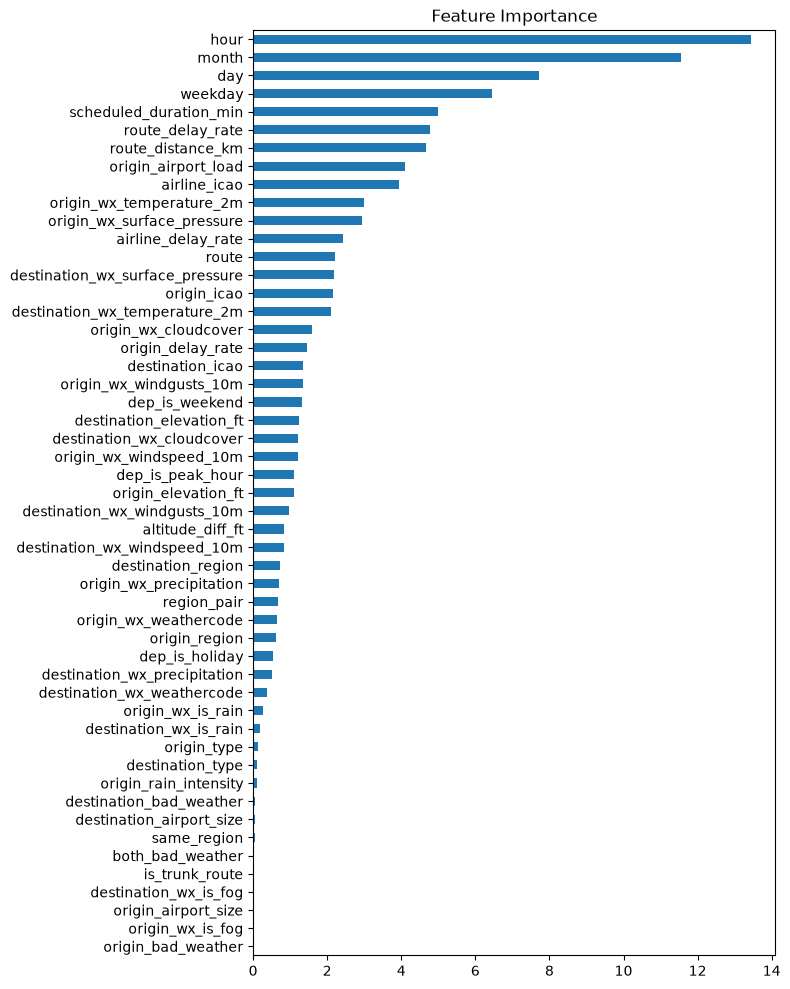

In [33]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model_cat.get_feature_importance(),
    index=X
).sort_values(ascending=True)


importance.plot(kind="barh", figsize=(8, 10), title="Feature Importance")
plt.tight_layout()
plt.show()
